# Task Overview

Your task will be to implement a variant of *ProxyProp* (Proximal Backpropagation) – a modification of backpropagation in which the weights of the network are not updated according to gradient descent, but according to [proximal mapping operator](https://en.wikipedia.org/wiki/Proximal_operator). This proximal operator in many cases results in a descent that is quicker than in the case of traditional gradient descent. Interestingly enough, the proximal operator arose in the context of gradient descent in which the minimized function is not differentiable, and gradient descent cannot be applied directly as we cannot compute the Jacobi matrix. This method is called [proximal gradient method](https://en.wikipedia.org/wiki/Proximal_gradient_method). However, we are interested here in the efficiency of the approach rather than its robustness. The backpropagation method in the proximal approach (i.e. *ProxyProp* algorithm) is described in detail in [this paper](https://arxiv.org/pdf/1706.04638v3).

The original algorithm presented in the paper uses purely linear transformations between subsequent network layers. Part of your task is to use affine transformations there, i.e. ones with biases.

You should use an MLP architecture trained on the MNIST dataset. You should implement the network in numpy.

Tasks:
1. (9pt) Fill missing code below
  - 1pt implement the `__init__` method
  - 2pt implement the feedforward method
  - 6pt implement the backpropagation
2. Train the models (find proper hyperparameters). Visualize the learning speed of your best model compared with the standard backpropagation (plot training loss for subsequent numbers of epochs using both algorithms). Your model should reach at least 94% accuracy. Use ClearML to log your scores. Make a comparison of memory usage for _ProxProp_ network and the network you implemented in lab 3.
  - 1pt for accuracy above 94%
  - 1pt for initialization of the standard backpropagation and ProxyProp with the same random values
  - 1pt for visualizations (we recommend downloading plots from clear ml)
  - 2pt if [clear ml](https://clear.ml/docs/latest/docs/) used properly
  - 1pt for comparing memory usage.

Part of the assignment consists of deriving proper formulas for a proposed slight modification of _ProxProp_. We do not grant points separately for this activity. You are rewarded for that only after proper implementation.


## Potential questions, clarifications
- Q: Can I modify code of _ProxyProp_ outside #Your code goes here # to include logging?
  - Yes, in ProxyProp.SGD
- Q: Can I modify the code of _Network_ to include logging?
  - Yes.

In [16]:
%pip install clearml
%pip install memory-profiler
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [17]:
import numpy as np
from clearml import Logger
from typing import List

In [18]:
%load_ext memory_profiler

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


# Dataset loading


In [19]:
!wget -O mnist.npz https://s3.amazonaws.com/img-datasets/mnist.npz

--2024-11-17 22:24:03--  https://s3.amazonaws.com/img-datasets/mnist.npz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.182.38.128, 16.182.39.128, 52.216.217.0, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.182.38.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11490434 (11M) [application/octet-stream]
Saving to: 'mnist.npz'

     0K .......... .......... .......... .......... ..........  0%  426K 26s
    50K .......... .......... .......... .......... ..........  0%  415K 26s
   100K .......... .......... .......... .......... ..........  1%  119M 18s
   150K .......... .......... .......... .......... ..........  1%  405K 20s
   200K .......... .......... .......... .......... ..........  2%  162M 16s
   250K .......... .......... .......... .......... ..........  2% 16,6M 13s
   300K .......... .......... .......... .......... ..........  3%  208K 19s
   350K .......... .......... .......... .......... ..........  3% 1,33M 17s
   400K ..

In [20]:
def load_mnist(path: str = "mnist.npz"):
    with np.load(path) as f:
        x_train, _y_train = f["x_train"], f["y_train"]
        x_test, _y_test = f["x_test"], f["y_test"]

    x_train = x_train.reshape(-1, 28 * 28) / 255.0
    x_test = x_test.reshape(-1, 28 * 28) / 255.0

    y_train = np.zeros((_y_train.shape[0], 10))
    y_train[np.arange(_y_train.shape[0]), _y_train] = 1

    y_test = np.zeros((_y_test.shape[0], 10))
    y_test[np.arange(_y_test.shape[0]), _y_test] = 1

    return (x_train, y_train), (x_test, y_test)


(x_train, y_train), (x_test, y_test) = load_mnist()

# Set up clear ml

In [21]:
### Your code goes here ###
from clearml import Task

web_server = 'https://app.clear.ml'
api_server = 'https://api.clear.ml'
files_server = 'https://files.clear.ml'
access_key = 'Q4NWNG3FEU5D6P3MMROF2T4SBH7VTF'
secret_key = 'a6kURIRUbWnnr11cw0bNW961HKDFxBd_cymeTkwl9y78mxQbm8EpZkEExGkRCmPlwzs'

Task.set_credentials(web_host=web_server,
                     api_host=api_server,
                     files_host=files_server,
                     key=access_key,
                     secret=secret_key)

###########################

# A quick recap of the backpropagation model

## Forward pass

We begin with $g^{(0)} = x$.

To apply forward pass, use the following formulas L times:

$$
%\begin{equation}
f^{(l + 1)} = W^{(l+1)} g^{(l)} + b^{(l+1)}
\nonumber
%\end{equation}
$$
$$
%\begin{equation}
g^{(l)} = \sigma(f^{(l)})
\nonumber
%\end{equation}
%\\
$$

$l = 1, 2, \ldots, L$.


Then, use output of the network is $g^{(L)}$ to compute the loss $L(y, g^{(L)})$.

## Backward pass

We begin with $\frac{\partial L}{\partial g^{(L)}}$, which can be computed directly.

To compute gradients, use the following formulas:

$$
%\begin{equation}
\frac{\partial L}{\partial f^{(l)}} = \frac{\partial L}{\partial g^{(l)}} \odot g^{(l)} \odot (1 - g^{(l)})
\nonumber
%\end{equation}
$$
$$
%\begin{equation}
\frac{\partial L}{\partial g^{(l)}} = (W^{(l+1)})^{T} \cdot \frac{\partial L}{\partial f^{(l+1)}}
\nonumber
%\end{equation}
$$
$$
%\begin{equation}
\frac{\partial L}{\partial b^{(l)}} = \frac{\partial L}{\partial f^{(l)}}
\nonumber
%\end{equation}
$$
$$
%\begin{equation}
\frac{\partial L}{\partial W^{(l)}} = \frac{\partial L}{\partial f^{(l)}} \cdot g^{(l-1)}
\nonumber
%\end{equation}
$$

$l = L, L-1, \ldots, 1$.

In [33]:
# Network definition (as in laboratory 3)

def sigmoid(z: np.ndarray) -> float:
    return 1.0 / (1.0 + np.exp(-z))


def logloss(
    x: np.ndarray,
    y: np.ndarray,
) -> float:
    return -(np.log(x) * y).sum() / y.shape[1]
class Network(object):
    def __init__(
        self,
        sizes: List[int],
    ) -> None:
        # initialize biases and weights with random normal distr.
        # weights are indexed by target node first
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])]

    def feedforward(
        self,
        a: np.ndarray,
    ) -> np.ndarray:
        # Run the network on a batch
        a = a.T
        for b, w in zip(self.biases, self.weights):
            a = sigmoid(np.matmul(w, a) + b)
        return a

    def update_mini_batch(
        self,
        mini_batch: tuple[np.ndarray, np.ndarray],
        eta: float,
    ):
        # Update networks weights and biases by applying a single step
        # of gradient descent using backpropagation to compute the gradient.
        # The gradient is computed for a mini_batch which is as in tensorflow API.
        # eta is the learning rate
        nabla_b, nabla_w, loss = self.backprop(mini_batch[0].T, mini_batch[1].T)

        self.weights = [
            w - (eta / len(mini_batch[0])) * nw for w, nw in zip(self.weights, nabla_w)
        ]
        self.biases = [
            b - (eta / len(mini_batch[0])) * nb for b, nb in zip(self.biases, nabla_b)
        ]
        return loss

    def backprop(
        self,
        x: np.ndarray,
        y: np.ndarray,
    ) -> tuple[np.ndarray, np.ndarray, float]:
        # For a single input (x,y) return a pair of lists.
        # First contains gradients over biases, second over weights.
        g = x
        gs = [g]  # list to store all the gs, layer by layer
        fs = []  # list to store all the fs, layer by layer
        for b, w in zip(self.biases, self.weights):
            f = np.dot(w, g) + b
            fs.append(f)
            g = sigmoid(f)
            gs.append(g)
        # backward pass <- both steps at once
        loss = logloss(gs[-1], y)
        dLdg = self.cost_derivative(gs[-1], y)
        dLdfs = []
        for w, g in reversed(list(zip(self.weights, gs[1:]))):
            dLdf = np.multiply(dLdg, np.multiply(g, 1 - g))
            dLdfs.append(dLdf)
            dLdg = np.matmul(w.T, dLdf)

        dLdWs = [np.matmul(dLdf, g.T) for dLdf, g in zip(reversed(dLdfs), gs[:-1])]
        dLdBs = [
            np.sum(dLdf, axis=1).reshape(dLdf.shape[0], 1) for dLdf in reversed(dLdfs)
        ]
        return (dLdBs, dLdWs, loss)

    def evaluate(
        self,
        test_data: tuple[np.ndarray, np.ndarray],
    ) -> float:
        # Count the number of correct answers for test_data
        pred = np.argmax(self.feedforward(test_data[0]), axis=0)
        corr = np.argmax(test_data[1], axis=1).T
        return np.mean(pred == corr)

    def cost_derivative(
        self,
        output_activations: np.ndarray,
        y: np.ndarray,
    ) -> np.ndarray:
        return output_activations - y

    ####### Modified to log the results before the training, so that it is easier to compare with ProxProp
    def SGD(
            self,
            training_data: np.ndarray,
            epochs: int,
            mini_batch_size: int,
            eta: float,
            test_data: np.ndarray = None,
            logger: Logger = None,
    ) -> None:
        x_train, y_train = training_data
        if test_data:
            x_test, y_test = test_data
        wloss = logloss(self.feedforward(x_train).T, y_train) / (
                x_train.shape[0] // mini_batch_size
        )
        for j in range(epochs + 1):
            if logger is not None:
                logger.report_scalar(
                    title="Loss", series="Original Backprop Loss", iteration=j, value=wloss
                )
            if test_data:
                acc = self.evaluate((x_test, y_test))
                if logger is not None:
                    logger.report_scalar(
                        title="Accuracy",
                        series="Original Backprop Accuracy",
                        iteration=j,
                        value=acc,
                    )
                print("Epoch: {0}, Accuracy: {1}, Loss: {2}".format(j, acc, wloss))
            else:
                print("Epoch: {0}".format(j))
            if j == epochs:
                break
            loss = 0
            for i in range(x_train.shape[0] // mini_batch_size):
                x_mini_batch = x_train[
                               (mini_batch_size * i) : (mini_batch_size * (i + 1))
                               ]
                y_mini_batch = y_train[
                               (mini_batch_size * i) : (mini_batch_size * (i + 1))
                               ]
                loss += self.update_mini_batch((x_mini_batch, y_mini_batch), eta)
            wloss = loss / (
                    x_train.shape[0] // mini_batch_size
            )  # we compute the average of the losses over the number of minibatches

# Simple check if all is fine
network = Network([784, 30, 30, 10])
network.SGD(
    (x_train, y_train),
    epochs=2,
    mini_batch_size=100,
    eta=3.0,
    test_data=(x_test, y_test),
)

Epoch: 0, Accuracy: 0.1055, Loss: 10.758809039520536
Epoch: 1, Accuracy: 0.7975, Loss: 1.4367488130441264
Epoch: 2, Accuracy: 0.8585, Loss: 0.6409770663548403


# The original ProxProp definition

Let us fix the notation for our network as in the following figure. We can see here a series of layers with $n_0,\ldots, n_{L-2}$ nodes. Each layer is composed of input nodes that depend linearly ($\phi$ operator) on the output nodes that depend non-linearly on the respective input nodes ($\sigma$ operator). The quality of the final output is measured by the final loss function ${\cal L}_y$ (typically $\frac{1}{2}\|\cdot\|^2$).




![image.png]( 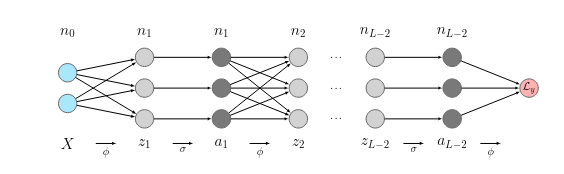)

_ProxProp_ procedure itself works similarly to a standard backpropagation procedure, as shown in the following figure.


![image.png]( 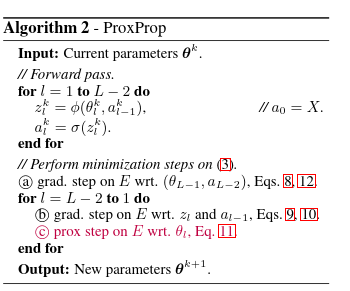)

For comparison, the standard backpropagation algorithm in this setting is as follows:


![image.png]( 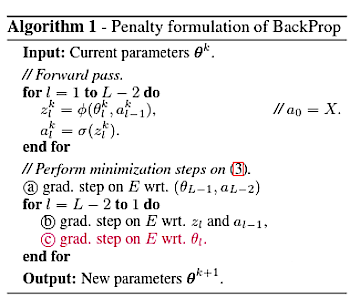)

Forward: The forward propagation phase is just as in the standard algorithm:

$z^k_l = \phi(\theta^k_l, a^k_{l−1}),$

$a^k_l = \sigma(z^k_l),$

where $\phi$ is supposed to be a linear transformation with weights $\theta^k_l$ over values $a^k_{l-1}$ and $\sigma$ is some non-linear step, e.g. the sigmoid function or the LeRU. You can use the sigmoid function for the purposes of this work.

Reverse: In the backpropagation, the step for the final layer ((a) on the figure) is exactly as in the gradient based version. In steps for the earlier layers, we recompute the z's and a's using the gradient method ((b) on the figure), but the weights are computed according to the proximal operator ((c) on the figure).

In step (a) the updated value is

$a'^{k}_{L−2} = a^k_{L−2} − \eta\nabla_{a_{L−2}} {\cal L}_y(\phi(\theta_{L−1}, a_{L−2})),$

where $\eta$ is the learning speed coefficient.

In case (b) the updated values are

$z'^{k}_l = z^k_l − \sigma'(z^k_l)(\sigma(z^k_l) − a'^k_l),$

$a'^{k}_{l−1} = a^k_{l−1} − \nabla( \frac{1}{2}\| \phi(θ^l, \cdot) − z'^k_l \|^2)(a^k_{l−1}),$

Note that the primed $a$-values are used to compute primed $z$-values and primed $z$-values are used to obtain the final value of $\theta^{k+1}$.

In case (c) the updated values are computed according to the proximal formula:

$$
\theta^{k+1}_l = \underset{\gamma}{\mathrm{argmin}} \left(\frac{1}{2} \|\phi(\gamma, a^k_{l−1}) − z'^k_l\|^2 + \frac{1}{2\tau_\theta}\|\gamma - \theta^k_l\|^2\right)
$$

The computation for the final layer is not done according to the proximity formula as it is difficult to obtain the closed formula for the necessary update, therefore it should be done according to the standard gradient descent.

The original formulas from the mentioned above paper do not use the biases. Part of the assignment is to rework this method so that the formulas include biases. You should develop a method in which biases are updated using the standard gradient descent method and the linear weight are updated using the _PropProx_ method with formulas adjusted to accommodate for biases.

# ProxProp similar to our backpropagation

Your task is to implement algorithm based on [ProxProp](https://arxiv.org/pdf/1706.04638v3). Please refer to the section above or section 4.2 in [the paper](https://arxiv.org/pdf/1706.04638v3) for algorithm description. Here we present the overview of the algorithm to be implemented.

## Forward pass

Forward pass is the same as in backpropagation implementation used in this course:
We begin with $g^{(0)} = x$.

To apply forward pass, use the following formulas L times:

$$
%\begin{equation}
f^{(l + 1)} = W^{(l+1)} g^{(l)} + b^{(l+1)}
\nonumber
%\end{equation}
$$
$$
%\begin{equation}
g^{(l)} = \sigma(f^{(l)})
\nonumber
%\end{equation}
%\\
$$

$l = 1, 2, \ldots, L$.


Then, use output of the network is $g^{(L)}$ to compute the loss $L(y, g^{(L)})$.

## Backward pass

We begin with $\frac{\partial L}{\partial g^{(L)}}$, which can be computed directly.

Gradients $\frac{\partial L}{\partial f^{(l)}}$, $\frac{\partial L}{\partial g^{(l)}}$ need to be computed.

$$
%\begin{equation}
\frac{\partial L}{\partial f^{(l)}} = \frac{\partial L}{\partial g^{(l)}} \odot g^{(l)} \odot (1 - g^{(l)})
\nonumber
%\end{equation}
$$
$$
%\begin{equation}
\frac{\partial L}{\partial g^{(l)}} = (W^{(l+1)})^{T} \cdot \frac{\partial L}{\partial f^{(l+1)}}
\nonumber
%\end{equation}
$$

For simplicity, biases will be updated as in standard backpropagation:
$$
%\begin{equation}
b^{(l)} = b^{(l)} - \eta \frac{\partial L}{\partial b^{(l)}}
\nonumber
%\end{equation}
$$
Remember to make the gradient update independent from the batch size by appropriate averaging!

Weights will be updated using values $f^{(l)}_{*}, g^{(l)}_{*}$. They are defined as follows:

$$
%\begin{equation}
g^{(L)}_{*} = g^{(L)} - \eta \frac{\partial L}{\partial g^{(L)}}
%\end{equation}
$$

$$
%\begin{equation}
f^{(l)}_{*} = f^{(l)} - \frac{\partial g^{(l)}}{\partial f^{(l)}} \cdot (g^{(l)} - g^{(l)}_{*})
%\end{equation}
$$

$l = 1, 2, \ldots, L$.

$$
%\begin{equation}
g^{(l)}_{*} = g^{(l)} - \frac{\partial f^{(l+1)}}{\partial g^{(l)}} \cdot (f^{(l+1)} - f^{(l+1)}_{*})
%\end{equation}
$$

$l = 1, 2, \ldots, L - 1$.

 The update of weights is defined as:

$$
%\begin{equation}
W^{(l)} = \text{arg min}_{W} \frac{1}{2} || W \cdot g^{(l-1)} + b^{(l)} - f^{(l)}_{*} ||^2 + \frac{1}{2\eta} || W - W^{(l)} ||^2
%\end{equation}
$$

$l = 1, 2, \ldots, L$.

Remarks:
* Weights are updated last (This means updated $b^{(l)}$ is used in the formula above).
* Please use closed form of the update assuming $W$ is a matrix. It might involve inverting some matrix. While it is not desirable in practice, the aim of this homework is to make you come up with the formula for the update :)
* Note that the original algorithm used two eta values. For the homework you should assume that these are equal and use for that only one parameter of the network.

---
**Original formula (in the paper) to update weights is**
$$\theta^{k+1}=\left(z^{k+1 / 2}\left(a^k\right)^{\top}+\frac{1}{\tau_\theta} \theta^k\right)\left(a^k\left(a^k\right)^{\top}+\frac{1}{\tau_\theta} I\right)^{-1}$$


**to include biases I have changed it to**
$$\theta^{k+1}=\left(\left(z^{k+1 / 2} - b \right)\left(a^k\right)^{\top}+\frac{1}{\tau_\theta} \theta^k\right)\left(a^k\left(a^k\right)^{\top}+\frac{1}{\tau_\theta} I\right)^{-1}$$

In [23]:
class ProxProp(object):
    def __init__(
            self,
            sizes: List[int],
    ) -> None:
        self.sizes = sizes
        # initialize biases and weights with random normal distr.
        # weights are indexed by target node first
        # IMPORTANT: use at least one layer of size a -> a
        ### Your code goes here ###
        self.num_layers = len(sizes)
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]] # size is (nodes, 1). Ex. (30, 1)
        self.weights = [np.random.randn(y, x) for x, y in zip(sizes[:-1], sizes[1:])] # size is (nodes, weights). Ex. (30, 784)
        ###########################

    def feedforward(
            self,
            a: np.ndarray,
    ) -> np.ndarray:
        # Run the network
        ### Your code goes here ###

        # `a` has size (samples, features). Ex. (10000, 784) 
        a = a.T
        for b, w in zip(self.biases, self.weights):
            a = sigmoid(np.matmul(w, a) + b)
        return a
        ###########################

    def backprop(self, x: np.ndarray, y: np.ndarray, eta: float) -> float:
        ### Your code goes here ###

        ######### Feedforward #########
        g = x # `x` is full batch. Ex. (784, 100)
        gs = [g]  # list to store all the gs, layer by layer
        fs = [np.zeros_like(g)]  # list to store all the fs, layer by layer. Added zeros layer so both gs and fs have equal lengths
        for b, w in zip(self.biases, self.weights):
            f = np.dot(w, g) + b
            fs.append(f)
            g = sigmoid(f)
            gs.append(g)
        loss = logloss(gs[-1], y)

        
        ######### Backprop to update biases #########
        dLdg = self.cost_derivative(gs[-1], y)
        for i, (w, f) in enumerate(reversed(list(zip(self.weights, fs[1:])))):
            dLdf = dLdg * sigmoid(f) * (1 - sigmoid(f))
            self.biases[-1 - i] -= eta * np.mean(dLdf, axis=1, keepdims=True)
            dLdg = w.T @ dLdf


        ######### Algorithm from the paper to update weights #########
        # These two loops below and the one above could have been replaced by just one, but I split them for readability.
        
        # f*, g* for the last layer
        gs_star = [gs[-1] - eta * self.cost_derivative(gs[-1], y)]
        fs_star = [fs[-1] - sigmoid(fs[-1]) * (1 - sigmoid(fs[-1])) * (gs[-1] - gs_star[-1])]

        # f*, g* for layers 1..(L-1)
        for l in reversed(range(self.num_layers-1)):
            gs_star.append(gs[l] - self.weights[l].T @ (fs[l+1] - fs_star[-1]))
            fs_star.append(fs[l] - sigmoid(fs[l]) * (1 - sigmoid(fs[l])) * (gs[l] - gs_star[-1]))
        fs_star = list(reversed(fs_star))

        # Update weights
        for i in range(len(self.weights)):
            # To include biases we change `f*` to `(f* - biases)` in the formula
            self.weights[i] = ((fs_star[i+1] - self.biases[i]) @ gs[i].T + 1/eta * self.weights[i]) @ np.linalg.inv(gs[i] @ gs[i].T + 1/eta * np.identity(gs[i].shape[0]))

        return loss

    def evaluate(
        self,
        test_data: tuple[np.ndarray, np.ndarray],
    ) -> float:
        pred = np.argmax(self.feedforward(test_data[0]), axis=0)
        corr = np.argmax(test_data[1], axis=1).T
        return np.mean(pred == corr)

    def cost_derivative(
        self,
        output_activations: np.ndarray,
        y: np.ndarray,
    ) -> np.ndarray:
        return output_activations - y

    def SGD(
        self,
        training_data: np.ndarray,
        epochs: int,
        mini_batch_size: int,
        eta: float,
        test_data: np.ndarray = None,
        logger: Logger = None,
    ) -> None:
        x_train, y_train = training_data
        if test_data:
            x_test, y_test = test_data
        wloss = logloss(self.feedforward(x_train).T, y_train) / (
            x_train.shape[0] // mini_batch_size
        )
        for j in range(epochs + 1):
            if logger is not None:
                logger.report_scalar(
                    title="Loss", series="ProxyProp Loss", iteration=j, value=wloss
                )
            if test_data:
                acc = self.evaluate((x_test, y_test))
                if logger is not None:
                    logger.report_scalar(
                        title="Accuracy",
                        series="ProxyProp Accuracy",
                        iteration=j,
                        value=acc,
                    )
                print("Epoch: {0}, Accuracy: {1}, Loss: {2}".format(j, acc, wloss))
            else:
                print("Epoch: {0}".format(j))
            if j == epochs:
                break
            loss = 0
            for i in range(x_train.shape[0] // mini_batch_size):
                x_mini_batch = x_train[
                    (mini_batch_size * i) : (mini_batch_size * (i + 1))
                ]
                y_mini_batch = y_train[
                    (mini_batch_size * i) : (mini_batch_size * (i + 1))
                ]
                loss += self.backprop(x_mini_batch.T, y_mini_batch.T, eta)
            wloss = loss / (
                x_train.shape[0] // mini_batch_size
            )  # we compute the average of the losses over the number of minibatches



# Simple check if all is fine
network = ProxProp([784, 30, 30, 10])
network.SGD(
    (x_train, y_train),
    epochs=2,
    mini_batch_size=100,
    eta=3.0,
    test_data=(x_test, y_test),
)

Epoch: 0, Accuracy: 0.1287, Loss: 9.129499268790031
Epoch: 1, Accuracy: 0.8583, Loss: 0.7976186970179838
Epoch: 2, Accuracy: 0.9012, Loss: 0.4437458653883867


# Train the network

I will use [Optuna](https://optuna.org) to find optimal *eta (learning rate)* for my ProxProp implementation.
In short, it is hyperparameter optimization framework to automate hyperparameter search.

My choice of the number of hidden layers and their sizes is a compromise between the accuracy and speed of training. 
- I didn't want a much smaller network because its results were usually worse. 
- I didn't make a larger network because its training time was too long.

Similarly, for `batch_size` 
- Small values like $16$ resulted in poor accuracy, while using $256$ meant too slow convergence and therefore long training time. 


In [1]:
!pip install optuna

In [24]:
### Your code goes here ###

import optuna
import tqdm

def objective(trial):
    eta = trial.suggest_float('eta', 1e-3, 100.0, log=True)

    network = ProxProp([784, 128, 128, 10])
    network.SGD(
        (x_train, y_train),
        epochs=10,
        mini_batch_size=64,
        eta=eta,
        test_data=(x_test, y_test)
    )

    accuracy = network.evaluate((x_test, y_test))
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2024-11-17 22:25:50,432] A new study created in memory with name: no-name-13e2eee9-d6d1-44eb-b876-d23d0953a1d4


Epoch: 0, Accuracy: 0.0796, Loss: 17.114033769515533
Epoch: 1, Accuracy: 0.9143, Loss: 0.8295842068045526
Epoch: 2, Accuracy: 0.934, Loss: 0.35376617808099786
Epoch: 3, Accuracy: 0.9392, Loss: 0.2681143671811957
Epoch: 4, Accuracy: 0.944, Loss: 0.22317349879171058
Epoch: 5, Accuracy: 0.947, Loss: 0.19495257950359343
Epoch: 6, Accuracy: 0.9476, Loss: 0.17449610334105342
Epoch: 7, Accuracy: 0.9496, Loss: 0.15895521847506688
Epoch: 8, Accuracy: 0.9492, Loss: 0.1481647281942926
Epoch: 9, Accuracy: 0.9498, Loss: 0.13689739436919923


[I 2024-11-17 22:39:49,265] Trial 0 finished with value: 0.9488 and parameters: {'eta': 5.838664641883227}. Best is trial 0 with value: 0.9488.


Epoch: 10, Accuracy: 0.9488, Loss: 0.1287293409538328
Epoch: 0, Accuracy: 0.17, Loss: 27.834214454930763
Epoch: 1, Accuracy: 0.1698, Loss: 4.357323736860652
Epoch: 2, Accuracy: 0.1694, Loss: 4.379257388040266
Epoch: 3, Accuracy: 0.1692, Loss: 4.40172466790889
Epoch: 4, Accuracy: 0.1691, Loss: 4.424721873350275
Epoch: 5, Accuracy: 0.1688, Loss: 4.448237988424911
Epoch: 6, Accuracy: 0.1676, Loss: 4.472254986223015
Epoch: 7, Accuracy: 0.1674, Loss: 4.496748352308536
Epoch: 8, Accuracy: 0.1675, Loss: 4.521687649291614
Epoch: 9, Accuracy: 0.1679, Loss: 4.5470369909591355


[I 2024-11-17 22:49:57,252] Trial 1 finished with value: 0.1681 and parameters: {'eta': 0.003387671590682761}. Best is trial 0 with value: 0.9488.


...

Epoch: 10, Accuracy: 0.9549, Loss: 0.17036027520588154
Epoch: 0, Accuracy: 0.0832, Loss: 16.269783698154413
Epoch: 1, Accuracy: 0.8717, Loss: 2.5369486993068238
Epoch: 2, Accuracy: 0.8887, Loss: 2.2970026616613186
Epoch: 3, Accuracy: 0.8982, Loss: 2.2483322791904827
Epoch: 4, Accuracy: 0.8994, Loss: 2.110482256766126
Epoch: 5, Accuracy: 0.9, Loss: 2.1327708852761673
Epoch: 6, Accuracy: 0.903, Loss: 2.321920647803779
Epoch: 7, Accuracy: 0.9072, Loss: 2.278373211636278
Epoch: 8, Accuracy: 0.9108, Loss: 2.239885458198985
Epoch: 9, Accuracy: 0.9101, Loss: 2.2050255384542603


[I 2024-11-18 06:39:33,775] Trial 48 finished with value: 0.9139 and parameters: {'eta': 30.28603045558504}. Best is trial 37 with value: 0.9574.


Epoch: 10, Accuracy: 0.9139, Loss: 2.253298806869345
Epoch: 0, Accuracy: 0.1105, Loss: 22.846971228259562
Epoch: 1, Accuracy: 0.7995, Loss: 1.9359078768814215
Epoch: 2, Accuracy: 0.9058, Loss: 0.9100853125757431
Epoch: 3, Accuracy: 0.9214, Loss: 0.37619025209108514
Epoch: 4, Accuracy: 0.9292, Loss: 0.32172102954030585
Epoch: 5, Accuracy: 0.933, Loss: 0.28710198863527464
Epoch: 6, Accuracy: 0.9355, Loss: 0.2623972581897252
Epoch: 7, Accuracy: 0.9371, Loss: 0.24310130364222102
Epoch: 8, Accuracy: 0.939, Loss: 0.22794714959663206
Epoch: 9, Accuracy: 0.9391, Loss: 0.2157695123614685


[I 2024-11-18 06:49:35,307] Trial 49 finished with value: 0.9409 and parameters: {'eta': 1.9661726754282471}. Best is trial 37 with value: 0.9574.


Epoch: 10, Accuracy: 0.9409, Loss: 0.2058660735143175


Optuna has an option to plot the results.

In [25]:
print("Best learning rate:", study.best_params['eta'])
print("Accuracy:", study.best_value)
optuna.visualization.plot_slice(study, ['eta'])

Best learning rate: 9.019942367434632
Accuracy: 0.9574


As can be seen `eta` around $9$ gives the best results (accuracy over $95$%), so I will use `eta=9` to train ProxProp in the next section.

I will also find the best `eta` for original backpropagation with the same network architecture, so comparison in the next section is fair.

In [26]:
def objective(trial):
    eta = trial.suggest_float('eta', 1e-2, 50.0, log=True)

    network = Network([784, 128, 128, 10])
    network.SGD(
        (x_train, y_train),
        epochs=20,
        mini_batch_size=64,
        eta=eta,
        test_data=(x_test, y_test)
    )

    accuracy = network.evaluate((x_test, y_test))
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

[I 2024-11-18 06:49:35,624] A new study created in memory with name: no-name-13058ff0-4364-43ba-abca-179c35242488


Epoch: 0, Accuracy: 0.073, Loss: 20.342650813724774
Epoch: 1, Accuracy: 0.4561, Loss: 7.126080432065486
Epoch: 2, Accuracy: 0.6282, Loss: 5.308221987431584
Epoch: 3, Accuracy: 0.7313, Loss: 3.7784215393289986
Epoch: 4, Accuracy: 0.7447, Loss: 3.5906160487596495
Epoch: 5, Accuracy: 0.7517, Loss: 3.5317126649768524
Epoch: 6, Accuracy: 0.7574, Loss: 3.5065525771963295
Epoch: 7, Accuracy: 0.7596, Loss: 3.497401267778238
Epoch: 8, Accuracy: 0.7606, Loss: 3.502933222132913
Epoch: 9, Accuracy: 0.7613, Loss: 3.5151455264155644
Epoch: 10, Accuracy: 0.7623, Loss: 3.5226659222765435
Epoch: 11, Accuracy: 0.7642, Loss: 3.5299267072799867
Epoch: 12, Accuracy: 0.7641, Loss: 3.5371003477260547
Epoch: 13, Accuracy: 0.765, Loss: 3.5437590762879982
Epoch: 14, Accuracy: 0.7658, Loss: 3.5506938150601894
Epoch: 15, Accuracy: 0.767, Loss: 3.558396637625687
Epoch: 16, Accuracy: 0.7678, Loss: 3.564079123692646
Epoch: 17, Accuracy: 0.7684, Loss: 3.5664139403330433
Epoch: 18, Accuracy: 0.7688, Loss: 3.5673483893

[I 2024-11-18 06:50:07,282] Trial 0 finished with value: 0.7699 and parameters: {'eta': 3.4780985955306916}. Best is trial 0 with value: 0.7699.


Epoch: 20, Accuracy: 0.7699, Loss: 3.5696144581474147
Epoch: 0, Accuracy: 0.0868, Loss: 25.17637393383473
Epoch: 1, Accuracy: 0.4777, Loss: 12.035723930857806
Epoch: 2, Accuracy: 0.5652, Loss: 7.805914823899828
Epoch: 3, Accuracy: 0.6519, Loss: 6.760735711500438
Epoch: 4, Accuracy: 0.6594, Loss: 6.686907248430738
Epoch: 5, Accuracy: 0.6634, Loss: 6.62876900763273
Epoch: 6, Accuracy: 0.6664, Loss: 6.594972397018057
Epoch: 7, Accuracy: 0.6683, Loss: 6.56856894908717
Epoch: 8, Accuracy: 0.6702, Loss: 6.561907029650789
Epoch: 9, Accuracy: 0.6706, Loss: 6.545835031415528
Epoch: 10, Accuracy: 0.6702, Loss: 6.532965540893778
Epoch: 11, Accuracy: 0.6704, Loss: 6.525974757323241
Epoch: 12, Accuracy: 0.671, Loss: 6.512093563729551
Epoch: 13, Accuracy: 0.6711, Loss: 6.509975489981739
Epoch: 14, Accuracy: 0.671, Loss: 6.499420168533243
Epoch: 15, Accuracy: 0.6711, Loss: 6.492159043597056
Epoch: 16, Accuracy: 0.6718, Loss: 6.4796902525850175
Epoch: 17, Accuracy: 0.672, Loss: 6.460048726065896
Epoch

[I 2024-11-18 06:50:38,820] Trial 1 finished with value: 0.6734 and parameters: {'eta': 5.750072106659003}. Best is trial 0 with value: 0.7699.


...

Epoch: 20, Accuracy: 0.9316, Loss: 0.2820375618515653
Epoch: 0, Accuracy: 0.0927, Loss: 29.404333688947602
Epoch: 1, Accuracy: 0.4278, Loss: 8.247738816156842
Epoch: 2, Accuracy: 0.466, Loss: 7.463010065574156
Epoch: 3, Accuracy: 0.5223, Loss: 6.8743524376673415
Epoch: 4, Accuracy: 0.6047, Loss: 6.112218525961964
Epoch: 5, Accuracy: 0.6244, Loss: 5.590752737019009
Epoch: 6, Accuracy: 0.631, Loss: 5.5210026960436
Epoch: 7, Accuracy: 0.6354, Loss: 5.488615000311247
Epoch: 8, Accuracy: 0.6389, Loss: 5.4662243331628
Epoch: 9, Accuracy: 0.6408, Loss: 5.4477930765049285
Epoch: 10, Accuracy: 0.6429, Loss: 5.430179623027033
Epoch: 11, Accuracy: 0.6449, Loss: 5.412037582834071
Epoch: 12, Accuracy: 0.6467, Loss: 5.39394491281837
Epoch: 13, Accuracy: 0.648, Loss: 5.376313859201253
Epoch: 14, Accuracy: 0.6488, Loss: 5.358808894203212
Epoch: 15, Accuracy: 0.6498, Loss: 5.341031029923352
Epoch: 16, Accuracy: 0.6501, Loss: 5.32209525000745
Epoch: 17, Accuracy: 0.6511, Loss: 5.300555283578308
Epoch: 1

[I 2024-11-18 07:10:08,241] Trial 38 finished with value: 0.6533 and parameters: {'eta': 0.7491066584474975}. Best is trial 22 with value: 0.9366.


Epoch: 20, Accuracy: 0.6533, Loss: 5.199730227874512
Epoch: 0, Accuracy: 0.1233, Loss: 20.742863126098538
Epoch: 1, Accuracy: 0.684, Loss: 4.20787526717369
Epoch: 2, Accuracy: 0.7108, Loss: 3.010045225634855
Epoch: 3, Accuracy: 0.7216, Loss: 2.802959005713827
Epoch: 4, Accuracy: 0.8156, Loss: 2.546914527248555
Epoch: 5, Accuracy: 0.8408, Loss: 1.4544577331901136
Epoch: 6, Accuracy: 0.8429, Loss: 1.4179903964546796
Epoch: 7, Accuracy: 0.8458, Loss: 1.4072190306139458
Epoch: 8, Accuracy: 0.8479, Loss: 1.3972577694338715
Epoch: 9, Accuracy: 0.8496, Loss: 1.38274155337071
Epoch: 10, Accuracy: 0.8509, Loss: 1.3627346140729215
Epoch: 11, Accuracy: 0.8525, Loss: 1.3365304669063591
Epoch: 12, Accuracy: 0.8538, Loss: 1.301112830018327
Epoch: 13, Accuracy: 0.8558, Loss: 1.2544373297200084
Epoch: 14, Accuracy: 0.8598, Loss: 1.1790173544385898
Epoch: 15, Accuracy: 0.9339, Loss: 0.6673247197861029
Epoch: 16, Accuracy: 0.9375, Loss: 0.2559025195586046
Epoch: 17, Accuracy: 0.9406, Loss: 0.23682409126

[I 2024-11-18 07:10:39,952] Trial 39 finished with value: 0.9444 and parameters: {'eta': 2.827417100787358}. Best is trial 39 with value: 0.9444.


Epoch: 20, Accuracy: 0.9444, Loss: 0.21031685061138186


In [27]:
print("Best learning rate:", study.best_params['eta'])
print("Accuracy:", study.best_value)
optuna.visualization.plot_slice(study, ['eta'])
###########################

Best learning rate: 2.827417100787358
Accuracy: 0.9444


We can see that `eta` close to $3$ gives the best results, so I will use `eta=3` for comparison with ProxProp.

# Training plots for the best training

In [35]:
### Your code goes here ###
def train_proxprop_best_model():
    config = {
        "layers": [784, 128, 128, 10],
        "epochs": 20,
        "mini_batch_size": 64,
        "eta": 9.0,
    }

    # Logging performance of my best ProxProp model
    task = Task.create(project_name='DNN_Homework_1', task_name='ProxProp_best_model')
    task.connect(config)
    task.mark_started()
    logger = task.get_logger()

    network = ProxProp(config["layers"])
    network.SGD(
        (x_train, y_train),
        epochs=config["epochs"],
        mini_batch_size=config["mini_batch_size"],
        eta=config["eta"],
        test_data=(x_test, y_test),
        logger=logger,
    )

    task.mark_completed()
    task.close()


def train_backprop():
    config = {
        "layers": [784, 128, 128, 10],
        "epochs": 20,
        "mini_batch_size": 64,
        "eta": 3.0,
    }

    # Logging performance for original backprop model
    task = Task.create(project_name='DNN_Homework_1', task_name='Backprop_to_compare_with_the_best_model')
    task.mark_started()
    task.connect(config)
    logger = task.get_logger()

    network = Network(config["layers"])
    network.SGD(
        (x_train, y_train),
        epochs=config["epochs"],
        mini_batch_size=config["mini_batch_size"],
        eta=config["eta"],
        test_data=(x_test, y_test),
        logger=logger,
    )

    task.mark_completed()
    task.close()

np.random.seed(1) # Setting fixed seed so corresponding random values are the same for PropProp and original backpropagation.
print("ProxProp:")
train_proxprop_best_model()

np.random.seed(1)
print("\nBackProp:")
train_backprop()
###########################

ProxProp:
Epoch: 0, Accuracy: 0.0641, Loss: 11.603748689619135
Epoch: 1, Accuracy: 0.9142, Loss: 0.8011405570147535
Epoch: 2, Accuracy: 0.9341, Loss: 0.4129995536550857
Epoch: 3, Accuracy: 0.9411, Loss: 0.3225218654738521
Epoch: 4, Accuracy: 0.9487, Loss: 0.27859294296103404
Epoch: 5, Accuracy: 0.9512, Loss: 0.23959905465447223
Epoch: 6, Accuracy: 0.95, Loss: 0.21349228256864466
Epoch: 7, Accuracy: 0.9536, Loss: 0.19591832218936836
Epoch: 8, Accuracy: 0.9523, Loss: 0.18115672039808536
Epoch: 9, Accuracy: 0.9559, Loss: 0.16508880475953241
Epoch: 10, Accuracy: 0.9542, Loss: 0.16080497296611712
Epoch: 11, Accuracy: 0.9542, Loss: 0.1546456269190653
Epoch: 12, Accuracy: 0.9549, Loss: 0.14313981024609426
Epoch: 13, Accuracy: 0.9562, Loss: 0.13820525832735425
Epoch: 14, Accuracy: 0.9565, Loss: 0.1353471163297456
Epoch: 15, Accuracy: 0.9566, Loss: 0.1291276360521151
Epoch: 16, Accuracy: 0.958, Loss: 0.12662252301549926
Epoch: 17, Accuracy: 0.9584, Loss: 0.12281111955260567
Epoch: 18, Accuracy:

### Plots

Models on ClearML:
- [ProxProp](https://app.clear.ml/projects/dc1394ded3ed44f793d1ce65e1e23bdc/experiments/77fdabcf532a4e51be9c7fad9048fcaf/output/execution)
- [Original backpropagation](https://app.clear.ml/projects/dc1394ded3ed44f793d1ce65e1e23bdc/experiments/172a79ee9d024b9d92a41ced4f612d52/output/execution)


*Images were sent in a .zip along with ipynb.*

- #### Accuracy

![](accuracy.png)



- #### Loss

![](loss.png)




- #### Loss log scale

![](log_loss.png)



Indeed, one can observe that ProxProp converges faster and achieves better results than original backpropagation.

# Compare memory usage

Hint: you can use memory-profiler library [link](https://pypi.org/project/memory-profiler/)

In [34]:
### Your code goes here ###

def train_proxprop_best_model():
    config = {
        "layers": [784, 2000, 2000, 10],
        "epochs": 1,
        "mini_batch_size": 60000,
        "eta": 9.0,
    }

    network = ProxProp(config["layers"])
    network.SGD(
        (x_train, y_train),
        epochs=config["epochs"],
        mini_batch_size=config["mini_batch_size"],
        eta=config["eta"],
        test_data=(x_test, y_test),
    )



def train_backprop():
    config = {
        "layers": [784, 2000, 2000, 10],
        "epochs": 1,
        "mini_batch_size": 60000,
        "eta": 3.0,
    }

    network = Network(config["layers"])
    network.SGD(
        (x_train, y_train),
        epochs=config["epochs"],
        mini_batch_size=config["mini_batch_size"],
        eta=config["eta"],
        test_data=(x_test, y_test),
    )


np.random.seed(1)
print("ProxProp:")
%memit train_proxprop_best_model()

np.random.seed(1)
print("\nBackProp:")
%memit train_backprop()

###########################

ProxProp:
Epoch: 0, Accuracy: 0.0861, Loss: 60282.285223946834
Epoch: 1, Accuracy: 0.0861, Loss: 10.04704753732447
peak memory: 11419.56 MiB, increment: 10807.35 MiB

BackProp:
Epoch: 0, Accuracy: 0.0861, Loss: 60282.285223946834
Epoch: 1, Accuracy: 0.0856, Loss: 10.04704753732447
peak memory: 7767.09 MiB, increment: 7154.75 MiB


For this test I have used large layers `[784, 2000, 2000, 10]` and `mini_batch_size=60000` to make the difference in memory usage more visible. During the test OS still had a lot of free memory.

As can be seen, ProxProp consumes more memory than original backpropagation (10.8 GiB vs 7.2 GiB). 
